# IMPORTS

In [31]:
import torch
import numpy as np
import pandas as pd
import time
from PIL import Image
import shutil
import random
import torch
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
import tensorflow as tf
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import CarliniLInfMethod
import tarfile
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image
import shutil
import random
import time

# Data and Machine Learning
import pandas as pd
import numpy as np
import tensorflow as tf

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms

# Adversarial Robustness Toolbox (ART)
import art
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod
from art.attacks.evasion import ProjectedGradientDescentPyTorch
from art.attacks.evasion import BasicIterativeMethod
from art.attacks.evasion import ProjectedGradientDescent
from art.attacks.evasion import CarliniLInfMethod
from art.defences.preprocessor import SpatialSmoothing, JpegCompression

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"ART version: {art.__version__}")
print("All libraries successfully imported.\n")

TensorFlow version: 2.20.0
PyTorch version: 2.2.2+cu121
ART version: 1.20.1
All libraries successfully imported.



# CONFIGURATIONS

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

MAKE_DATASET_ONE_PER_PERSON = False
WORKER = "Salvatore"

# Base project directories
DATA_DIR = './dataset' 
MODELS_DIR   = './models'
RESULTS_DIR = './results'

DATA_DIR_100 = os.path.join(DATA_DIR, 'dataset_1_per_person')                  # Dataset dir for DF and Carlini Wagner with 100 images (1 per subject)
DATA_DIR_1000 = os.path.join(DATA_DIR, 'dataset_100_subjects')                 # Dataset dir for PGD, FGSM and BIM attacks with 1000 images (10 per subject)
CSV_PATH = os.path.join(DATA_DIR, 'selected_100_subjects.csv')                 # CSV file with metadata for the 100 subjects used in the dataset
ADVERSARIAL_DATA_DIR = os.path.join(DATA_DIR, 'adversarial_data')              # Base directory for all adversarial examples generated in the project
BASE_ADVERSARIAL_CW_DIR = os.path.join(ADVERSARIAL_DATA_DIR, 'CW_Untargeted')  # Directory for Carlini Wagner untargeted adversarial examples
BATCH_SIZE  = 64


# MODELS
print("\nLoading InceptionResnetV1 (NN1)")
nn1 = InceptionResnetV1(pretrained='vggface2').eval().to(device)
nn1.classify = True



Using: cuda

Loading InceptionResnetV1 (NN1)


# Dataset Preparation

This step verifies whether the datasets have already been prepared. If the extracted
dataset folders and the subject CSV are found locally, the step is skipped entirely.

Two datasets are prepared:
- `dataset_100_subjects`: 10 images per subject (1000 total), used for FGSM, BIM, and PGD.
- `dataset_1_per_person`: 1 image per subject (100 total), used for DeepFool and Carlini-Wagner,
  which are significantly slower and cannot be run on the full 1000-image dataset.

If neither dataset is found, the metadata CSV is read to select 100 subjects from the
VGGFace2 training set, images are extracted from the local TAR archive, and the
1-per-person subset is derived from the extracted data.



In [ ]:
# ==============================================================================
# STEP 1: Dataset Preparation
# ==============================================================================

print("Starting Dataset Preparation...")

# ------------------------------------------------------------------------------
# 1.0 Check if both datasets are already prepared
# ------------------------------------------------------------------------------
if os.path.exists(CSV_PATH) and os.path.exists(DATA_DIR_1000) and os.path.exists(DATA_DIR_100):
    selected_subjects = pd.read_csv(CSV_PATH)
    print(f"All datasets already prepared. Loaded {len(selected_subjects)} subjects from existing CSV.")

else:
    # --------------------------------------------------------------------------
    # 1.1 Process Metadata CSV and select 100 subjects
    # --------------------------------------------------------------------------
    if not os.path.exists(CSV_PATH):
        print("Metadata CSV not found. Processing VGGFace2 metadata...")

        LOCAL_META_CSV = os.path.join(DATA_DIR, 'vggface2_meta.csv')
        if not os.path.exists(LOCAL_META_CSV):
            raise FileNotFoundError(
                f"Metadata CSV not found at {LOCAL_META_CSV}. "
                "Place vggface2_meta.csv in the dataset directory before running this step."
            )

        df = pd.read_csv(LOCAL_META_CSV, on_bad_lines='skip', skipinitialspace=True)
        df.columns = df.columns.str.strip()

        if 'Sample_Num' not in df.columns:
            df.columns = ['Class_ID', 'Name', 'Sample_Num', 'Flag', 'Gender']

        df['Sample_Num'] = pd.to_numeric(df['Sample_Num'], errors='coerce')
        df['Flag']       = pd.to_numeric(df['Flag'],       errors='coerce')

        df_filtered = df[(df['Sample_Num'] >= 10) & (df['Flag'] == 1)].copy()
        df_filtered.loc[:, 'Class_ID'] = df_filtered['Class_ID'].astype(str).str.strip()

        selected_subjects = df_filtered.sample(n=100, random_state=42)
        target_ids = {class_id: 0 for class_id in selected_subjects['Class_ID']}

        # Normalize commas in Name column to match the official VGGFace2 label format
        selected_subjects['Name'] = (selected_subjects['Name']
                                    .str.replace(',_', '_', regex=False)
                                    .str.replace(',',  '_', regex=False))

        selected_subjects.to_csv(CSV_PATH, index=False)
        print(f"Saved metadata for 100 selected subjects to: {CSV_PATH}")
    else:
        selected_subjects = pd.read_csv(CSV_PATH)
        target_ids = {class_id: 0 for class_id in selected_subjects['Class_ID']}
        print(f"Loaded {len(selected_subjects)} subjects from existing CSV.")

    # --------------------------------------------------------------------------
    # 1.2 Extract 10 images per subject from the TAR archive (1000 images total)
    # --------------------------------------------------------------------------
    if not os.path.exists(DATA_DIR_1000):
        os.makedirs(DATA_DIR_1000, exist_ok=True)

        LOCAL_TAR_PATH = os.path.join(DATA_DIR, 'vggface2.tar.gz')
        if not os.path.exists(LOCAL_TAR_PATH):
            raise FileNotFoundError(
                f"TAR archive not found at {LOCAL_TAR_PATH}. "
                "Place vggface2.tar.gz in the dataset directory before running this step."
            )
        print("\nStarting extraction of 10 images per subject...")
        IMAGES_PER_SUBJECT = 10
        total_needed       = len(target_ids) * IMAGES_PER_SUBJECT
        total_extracted    = 0
        try:
            with tarfile.open(LOCAL_TAR_PATH, 'r:*') as tar:
                for member in tar.getmembers():
                    if total_extracted >= total_needed:
                        print(f"\nExtraction complete: {total_extracted} images collected.")
                        break

                    if member.isfile():
                        parts = member.name.split('/')
                        if len(parts) >= 2 and parts[-1].lower().endswith(('.jpg', '.jpeg', '.png')):
                            class_id = parts[-2].strip()

                            if class_id in target_ids and target_ids[class_id] < IMAGES_PER_SUBJECT:
                                dest_folder = os.path.join(DATA_DIR_1000, class_id)
                                os.makedirs(dest_folder, exist_ok=True)

                                extracted_f = tar.extractfile(member)
                                if extracted_f is not None:
                                    with open(os.path.join(dest_folder, parts[-1]), 'wb') as out:
                                        shutil.copyfileobj(extracted_f, out)

                                    target_ids[class_id] += 1
                                    total_extracted      += 1

                                    if total_extracted % 100 == 0:
                                        print(f"  Progress: {total_extracted}/{total_needed} images extracted...")

        except Exception as e:
            print(f"\nAn error occurred during extraction: {e}")

        print("10-images-per-subject dataset preparation completed.")
    else:
        print(f"Dataset '{DATA_DIR_1000}' already exists. Skipping extraction.")

    # --------------------------------------------------------------------------
    # 1.3 Build 1-per-person subset from the extracted dataset
    # --------------------------------------------------------------------------
    if not os.path.exists(DATA_DIR_100):
        os.makedirs(DATA_DIR_100, exist_ok=True)

        print("\nBuilding 1-per-person subset for DeepFool and Carlini-Wagner attacks...")

        rng             = random.Random(42)
        processed_count = 0

        for subject_folder in os.listdir(DATA_DIR_1000):
            subject_path = os.path.join(DATA_DIR_1000, subject_folder)

            if os.path.isdir(subject_path):
                images = [
                    f for f in os.listdir(subject_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                ]

                if images:
                    selected_image = rng.choice(images)
                    ext            = os.path.splitext(selected_image)[1]
                    new_filename   = f"{subject_folder}{ext}"

                    shutil.copy2(
                        os.path.join(subject_path, selected_image),
                        os.path.join(DATA_DIR_100, new_filename)
                    )
                    processed_count += 1

        print(f"1-per-person subset completed: {processed_count} images saved to {DATA_DIR_100}.")
    else:
        print(f"Dataset '{DATA_DIR_100}' already exists. Skipping subset creation.")

print("\nDataset preparation completed.")

## NN1 Baseline Evaluation

This step loads the target model NN1 (InceptionResnetV1 pretrained on VGGFace2)
and evaluates its accuracy on the 1000-image clean test set. The resulting baseline
accuracy is the reference point against which all adversarial attacks will be measured.

In [21]:
# ==============================================================================
# STEP 2: Baseline Evaluation
# ==============================================================================

print("NN1 Setup and Baseline Evaluation...")


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ------------------------------------------------------------------------------
# 2.1 Load Metadata Mapping (ID to Name)
# ------------------------------------------------------------------------------
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Metadata CSV not found at {CSV_PATH}. Run Step 1 first.")

selected_subjects = pd.read_csv(CSV_PATH)
id_to_name = dict(zip(
    selected_subjects['Class_ID'].astype(str).str.strip(),
    selected_subjects['Name'].astype(str).str.strip()
))
print("Metadata loaded for label matching.")

# ------------------------------------------------------------------------------
# 2.2 Load NN1 and Official Labels
# ------------------------------------------------------------------------------
print("Downloading official VGGFace2 label mapping...")
fpath = tf.keras.utils.get_file(
    'rcmalli_vggface_labels_v2.npy',
    "https://github.com/rcmalli/keras-vggface/releases/download/v2.0/rcmalli_vggface_labels_v2.npy",
    cache_subdir=str(MODELS_DIR)
)
LABELS = np.load(fpath, allow_pickle=True)
print("Model and labels loaded successfully.")

# ------------------------------------------------------------------------------
# 2.3 Define Preprocessing
# ------------------------------------------------------------------------------
# InceptionResnetV1 expects inputs resized to 160x160 and normalized to [-1, 1]
preprocess = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ------------------------------------------------------------------------------
# 2.4 Build Image List
# ------------------------------------------------------------------------------
image_paths     = []
true_folder_ids = []

for class_id in os.listdir(DATA_DIR_1000):
    class_folder = os.path.join(DATA_DIR_1000, class_id)
    if not os.path.isdir(class_folder):
        continue
    for img_name in os.listdir(class_folder):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(class_folder, img_name))
            true_folder_ids.append(class_id.strip())

# ------------------------------------------------------------------------------
# 2.5 Evaluate Baseline Accuracy
# ------------------------------------------------------------------------------
print(f"\nEvaluating baseline accuracy on {len(image_paths)} images...")
correct_predictions = 0

with tqdm(total=len(image_paths), desc="Evaluating", unit="img") as pbar:
    for img_path, true_id in zip(image_paths, true_folder_ids):
        try:
            img        = Image.open(img_path).convert('RGB')
            img_tensor = preprocess(img).unsqueeze(0).to(device)

            with torch.no_grad():
                preds         = nn1(img_tensor)
                predicted_idx = np.array(preds[0].detach().cpu().numpy()).argmax()

            raw_label = LABELS[predicted_idx]
            if isinstance(raw_label, np.ndarray):
                raw_label = raw_label.flatten()[0]
            if isinstance(raw_label, bytes):
                raw_label = raw_label.decode('utf-8')

            predicted_name = str(raw_label).replace("b'", "").replace("'", "").replace("[", "").replace("]", "").strip()
            true_name      = id_to_name.get(true_id, "Unknown")

            pred_clean = predicted_name.lower().replace(" ", "_").replace(",_", "_").replace(",", "_")
            true_clean = true_name.lower().replace(" ", "_").replace(",_", "_").replace(",", "_")

            if pred_clean == true_clean:
                correct_predictions += 1
            else:
                print(f"\nMisclassification for {os.path.basename(img_path)}:")
                print(f"  -> True: {true_clean} (ID: {true_id})  |  Predicted: {pred_clean}")

        except Exception as e:
            print(f"Error processing {img_path}: {e}")

        pbar.update(1)

# ------------------------------------------------------------------------------
# 2.6 Results
# ------------------------------------------------------------------------------
total_images   = len(image_paths)
clean_accuracy = (correct_predictions / total_images) * 100 if total_images > 0 else 0.0

BASELINE_ACC = clean_accuracy

print("\n" + "=" * 50)
print("NN1 - BASELINE EVALUATION RESULTS")
print("=" * 50)
print(f"Total Images Evaluated:  {total_images}")
print(f"Correct Predictions:     {correct_predictions}")
print(f"Baseline Accuracy (NN1): {clean_accuracy:.2f}%")
print("=" * 50 + "\n")


NN1 Setup and Baseline Evaluation...
Using device: cuda
Metadata loaded for label matching.
Model and labels loaded successfully.

Evaluating baseline accuracy on 1000 images...


Evaluating:   0%|          | 0/1000 [00:00<?, ?img/s]


Misclassification for 0051_02.jpg:
  -> True: aaron_rodgers (ID: n000017)  |  Predicted: kevin_youkilis

Misclassification for 0257_01.jpg:
  -> True: aaron_rodgers (ID: n000017)  |  Predicted: jarret_stoll

Misclassification for 0352_02.jpg:
  -> True: aaron_rodgers (ID: n000017)  |  Predicted: bojan_krkić

Misclassification for 0466_03.jpg:
  -> True: alessandra_amoroso (ID: n000236)  |  Predicted: susannah_constantine

Misclassification for 0434_02.jpg:
  -> True: baltasar_garzón (ID: n000879)  |  Predicted: laurent_blanc

Misclassification for 0010_01.jpg:
  -> True: beren_saat (ID: n000973)  |  Predicted: pilar_rubio

Misclassification for 0213_01.jpg:
  -> True: beren_saat (ID: n000973)  |  Predicted: aída_román

Misclassification for 0273_01.jpg:
  -> True: beren_saat (ID: n000973)  |  Predicted: saige_ryan_campbell

Misclassification for 0089_01.jpg:
  -> True: bobbi_sue_luther (ID: n001116)  |  Predicted: sarah_harding

Misclassification for 0168_01.jpg:
  -> True: bobbi_sue_

## Adversarial Attacks Setup and Helper Functions

This step initializes all shared components required by the adversarial attack pipeline:
the ART classifier wrapper around NN1, the attack preprocessing transform, and three
helper functions used by every subsequent attack step (image saving, Security Evaluation
Curve plotting, and adversarial archive management).


In [ ]:
# ==============================================================================
# STEP 3.0: Adversarial Attacks Setup and Helper Functions
# ==============================================================================

print("Initializing adversarial attack setup and helper functions...")

# ------------------------------------------------------------------------------
# 3.0.1 ART Classifier Wrapper
# ------------------------------------------------------------------------------
criterion = nn.CrossEntropyLoss()

# ART expects inputs in [0, 1] and handles the normalization shift to [-1, 1] internally.
art_classifier = PyTorchClassifier(
    model=nn1,
    clip_values=(0.0, 1.0),
    loss=criterion,
    optimizer=None,
    input_shape=(3, 160, 160),
    nb_classes=8631,
    preprocessing=(np.array([0.5, 0.5, 0.5]), np.array([0.5, 0.5, 0.5])),
    device_type='gpu' if torch.cuda.is_available() else 'cpu'
)

# Preprocessing for attack generation: only resize and ToTensor.
# Normalization to [-1, 1] is delegated to the ART wrapper above.
preprocess_attack = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

# ------------------------------------------------------------------------------
# Helper 1: Label Normalization
# ------------------------------------------------------------------------------
def normalize_label(label: str) -> str:
    """
    Normalizes a subject name string for safe comparison against official VGGFace2 labels.
    Converts to lowercase, replaces spaces with underscores, and removes commas.
    """
    return label.lower().replace(" ", "_").replace(",_", "_").replace(",", "_")

# ------------------------------------------------------------------------------
# Helper 2: Image Saving
# ------------------------------------------------------------------------------
def save_adversarial_images(adv_examples, true_labels, filenames, attack_name, epsilon):
    """
    Saves adversarial examples generated by ART as PNG image files.

    ART outputs arrays in the [0.0, 1.0] range due to clip_values=(0.0, 1.0).
    Each image is scaled to [0, 255], transposed from (C, H, W) to (H, W, C),
    and saved under ADVERSARIAL_DATA_DIR//eps_//.png.
    """
    eps_folder_name = f"eps_{epsilon:.3f}".replace('.', '_')
    save_dir = os.path.join(ADVERSARIAL_DATA_DIR, attack_name, eps_folder_name)

    for i in range(len(adv_examples)):
        class_id   = str(true_labels[i]).strip()
        base_name  = os.path.splitext(str(filenames[i]))[0]
        subject_dir = os.path.join(save_dir, class_id)
        os.makedirs(subject_dir, exist_ok=True)

        img_array = (adv_examples[i] * 255).astype(np.uint8)
        img_array = np.transpose(img_array, (1, 2, 0))
        Image.fromarray(img_array, mode='RGB').save(
            os.path.join(subject_dir, f"{base_name}.png")
        )

# ------------------------------------------------------------------------------
# Helper 3: Security Evaluation Curve
# ------------------------------------------------------------------------------
def plot_security_evaluation_curve(epsilons, accuracies, attack_name, save_dir, baseline_acc=BASELINE_ACC):
    """
    Generates and saves a Security Evaluation Curve (SEC) for a given attack.

    The curve plots model accuracy as a function of the perturbation budget epsilon,
    connecting the clean baseline point (epsilon=0) to the first attack measurement
    and continuing through all evaluated epsilon values.
    """
    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(9, 6))

    plt.plot([0.0, epsilons[0]], [baseline_acc, accuracies[0]],
            linestyle='-', color='#ff7f0e', linewidth=1.5)
    plt.plot(epsilons, accuracies,
            marker='o', linestyle='-', color='#ff7f0e',
            linewidth=1.5, markersize=6, label=f'NN1 Performance ({attack_name})')
    plt.plot(0.0, baseline_acc,
            marker='o', markerfacecolor='#ff7f0e', markeredgecolor='#2ca02c',
            markeredgewidth=1, markersize=6, linestyle='None',
            label=f'Baseline Accuracy ({baseline_acc:.2f}%)')

    plt.title(f'Security Evaluation Curve - {attack_name}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(r'Perturbation Budget ($\epsilon$ - $L_\infty$ Norm)', fontsize=14)
    plt.ylabel('Model Accuracy (%)', fontsize=14)
    plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    plt.xticks(np.arange(0.0, 0.11, 0.01), fontsize=12)
    plt.yticks(np.arange(0, 101, 10), fontsize=12)
    plt.ylim(-5, 105)
    plt.xlim(-0.005, 0.105)
    plt.axvline(x=0.1, color='black', linestyle=':', linewidth=2,
                label=r'Max Allowable $\epsilon$ (0.1)')
    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()

    plot_path = os.path.join(save_dir, f'{attack_name}_SEC.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n[INFO] SEC graph saved at: {plot_path}")
    
    
    
def plot_iteration_evaluation_curve(iterations, accuracies, attack_name, save_dir, fixed_eps):
    """
    Generates and saves a curve plotting model accuracy against the number of PGD iterations.
    """
    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(9, 6))

    plt.plot(iterations, accuracies,
            marker='s', linestyle='-', color='#d62728',
            linewidth=1.5, markersize=6, label=f'NN1 Performance ({attack_name})')

    plt.title(f'Iteration Impact Curve - {attack_name} (Fixed $\epsilon$ = {fixed_eps})', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Number of Iterations (max_iter)', fontsize=14)
    plt.ylabel('Model Accuracy (%)', fontsize=14)
    plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    plt.xticks(iterations, fontsize=12)
    plt.yticks(np.arange(0, 101, 10), fontsize=12)
    plt.ylim(-5, 105)
    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()

    plot_path = os.path.join(save_dir, f'{attack_name}_Iteration_Impact.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"\n[INFO] Iteration impact graph saved at: {plot_path}")

print("Adversarial attack setup completed successfully.")

Initializing adversarial attack setup and helper functions...
Adversarial attack setup completed successfully.


# Error-Generic Attacks


## Fast Gradient Sign Method (FGSM)
This step evaluates the effect of the FGSM error-generic (untargeted) attack on NN1
across a range of epsilon values. For each epsilon, adversarial examples are generated
in batches, the model accuracy is re-evaluated, and the results are saved. A Security
Evaluation Curve is plotted at the end of the sweep, and a CSV summary of all results
is written to the results directory.



Initializing FGSM Attack Pipeline...

Starting FGSM generation across 7 epsilon values...

--- Evaluating Epsilon: 0.001 ---


Processing Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy at eps=0.001: 77.10%

--- Evaluating Epsilon: 0.003 ---


Processing Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy at eps=0.003: 45.90%

--- Evaluating Epsilon: 0.005 ---


...

Accuracy at eps=0.030: 1.60%

--- Evaluating Epsilon: 0.050 ---


Processing Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy at eps=0.050: 0.70%

--- Evaluating Epsilon: 0.100 ---


Processing Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy at eps=0.100: 0.10%

[INFO] Results saved at: ./results\FGSM\FGSM_results.csv


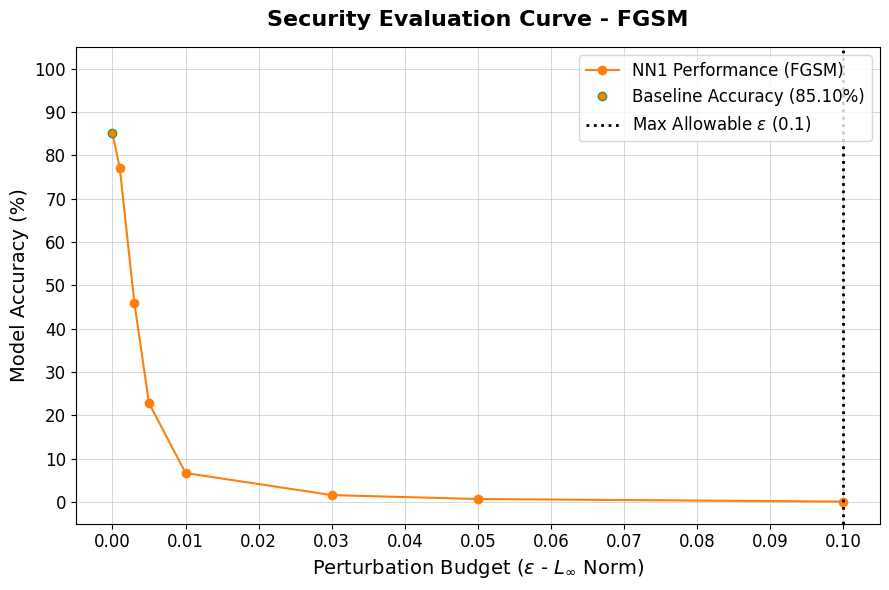


[INFO] SEC graph saved at: ./results\FGSM\FGSM_SEC.png

FGSM ATTACK SUMMARY REPORT
Evaluated Epsilon Range:  0.001 to 0.1
Baseline Accuracy:        85.10%
Lowest Accuracy:          0.10%
--------------------------------------------------
Total Model Degradation:  85.00%



In [ ]:
# ==============================================================================
# STEP 3.1: Fast Gradient Sign Method (FGSM) — Error-Generic Attack
# ==============================================================================

print("Initializing FGSM Attack Pipeline...")

# ------------------------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------------------------
ATTACK_NAME = "FGSM"
EPSILONS    = [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1]

ATTACK_RESULTS_DIR = os.path.join(RESULTS_DIR, ATTACK_NAME)
os.makedirs(ATTACK_RESULTS_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# 2. Evaluation Loop
# ------------------------------------------------------------------------------
print(f"\nStarting {ATTACK_NAME} generation across {len(EPSILONS)} epsilon values...")

results    = []
accuracies = []

for eps in EPSILONS:
    print(f"\n--- Evaluating Epsilon: {eps:.3f} ---")

    fgsm = FastGradientMethod(estimator=art_classifier, eps=eps)

    correct_predictions = 0
    total_processed     = 0
    start_time          = time.time()

    for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Processing Batches"):
        batch_paths    = image_paths[i:i + BATCH_SIZE]
        batch_true_ids = true_folder_ids[i:i + BATCH_SIZE]

        batch_tensors  = []
        batch_filenames = []
        for path in batch_paths:
            img = Image.open(path).convert('RGB')
            batch_tensors.append(preprocess_attack(img).numpy())
            batch_filenames.append(os.path.basename(path))

        x_batch = np.stack(batch_tensors)
        x_adv   = fgsm.generate(x=x_batch)

        preds        = art_classifier.predict(x_adv)
        pred_indices = np.argmax(preds, axis=1)

        for j, pred_idx in enumerate(pred_indices):
            raw_label = LABELS[pred_idx]
            if isinstance(raw_label, np.ndarray):
                raw_label = raw_label.flatten()[0]
            if isinstance(raw_label, bytes):
                raw_label = raw_label.decode('utf-8')

            predicted_name = str(raw_label).replace("b'", "").replace("'", "").replace("[", "").replace("]", "").strip()
            true_name      = id_to_name.get(batch_true_ids[j], "Unknown")

            if normalize_label(predicted_name) == normalize_label(true_name):
                correct_predictions += 1

        save_adversarial_images(x_adv, batch_true_ids, batch_filenames, ATTACK_NAME, eps)
        total_processed += len(batch_paths)

    elapsed = time.time() - start_time
    acc     = (correct_predictions / total_processed) * 100
    accuracies.append(acc)

    print(f"Accuracy at eps={eps:.3f}: {acc:.2f}%")

    results.append({
        'attack_name':          ATTACK_NAME,
        'epsilon':              eps,
        'correct_predictions':  correct_predictions,
        'total_images':         total_processed,
        'accuracy':             round(acc, 2),
        'time_elapsed_s':       round(elapsed, 2)
    })

# ------------------------------------------------------------------------------
# 3. Save Results CSV
# ------------------------------------------------------------------------------
df_results  = pd.DataFrame(results)
csv_path    = os.path.join(ATTACK_RESULTS_DIR, f'{ATTACK_NAME}_results.csv')
df_results.to_csv(csv_path, index=False)
print(f"\n[INFO] Results saved at: {csv_path}")

# ------------------------------------------------------------------------------
# 4. Security Evaluation Curve
# ------------------------------------------------------------------------------
plot_security_evaluation_curve(EPSILONS, accuracies, ATTACK_NAME, ATTACK_RESULTS_DIR)

# ------------------------------------------------------------------------------
# 5. Attack Summary
# ------------------------------------------------------------------------------
print("\n" + "=" * 50)
print(f"{ATTACK_NAME} ATTACK SUMMARY REPORT")
print("=" * 50)
print(f"Evaluated Epsilon Range:  {EPSILONS[0]} to {EPSILONS[-1]}")
print(f"Baseline Accuracy:        {BASELINE_ACC:.2f}%")
print(f"Lowest Accuracy:          {accuracies[-1]:.2f}%")
print("-" * 50)
print(f"Total Model Degradation:  {(BASELINE_ACC - accuracies[-1]):.2f}%")
print("=" * 50 + "\n")

## Projected Gradient Descent (PGD) — Error-Generic Attack

This step evaluates the effect of the PGD error-generic (untargeted) attack on NN1.
PGD extends BIM by adding random restarts: before each optimization, the starting
point is perturbed by a random offset sampled uniformly within the L-infinity ball
of radius epsilon. The parameter `num_random_init` controls how many random restarts
are performed, with `num_random_init=0` reducing PGD to standard BIM.
The attack is evaluated across all combinations of `epsilon`, `max_iter`, and
`num_random_init`, producing individual SECs, comparative plots, and hyperparameter
effect plots. A CSV summary of all results is written to the results directory.

Initializing PGD Attack Pipeline...

Starting PGD generation across 4 num_random_init values x 5 max_iter values x 7 epsilon values...

##################################################
NUM_RANDOM_INIT = 0
##################################################

MAX_ITER = 1 | NUM_RANDOM_INIT = 0

--- Evaluating Epsilon: 0.001 | max_iter: 1 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.001 | max_iter=1 | num_random_init=0: 77.10%

--- Evaluating Epsilon: 0.003 | max_iter: 1 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.003 | max_iter=1 | num_random_init=0: 45.70%

--- Evaluating Epsilon: 0.005 | max_iter: 1 | num_random_init: 0 ---


...

Accuracy at eps=0.030 | max_iter=1 | num_random_init=0: 1.70%

--- Evaluating Epsilon: 0.050 | max_iter: 1 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.050 | max_iter=1 | num_random_init=0: 0.70%

--- Evaluating Epsilon: 0.100 | max_iter: 1 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.100 | max_iter=1 | num_random_init=0: 0.10%


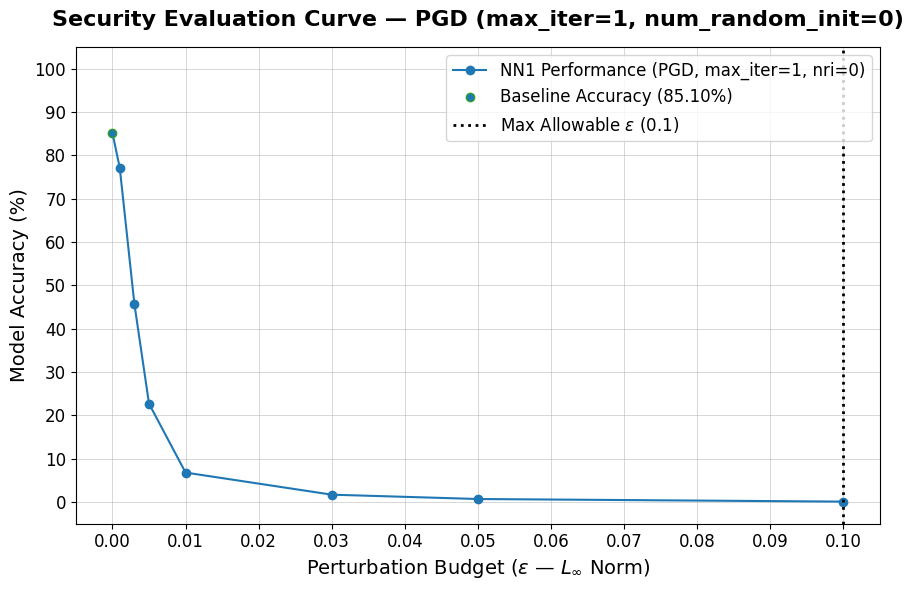


[INFO] Individual SEC saved at: ./results\PGD\PGD_nri0_iter1_SEC.png

MAX_ITER = 5 | NUM_RANDOM_INIT = 0

--- Evaluating Epsilon: 0.001 | max_iter: 5 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.001 | max_iter=5 | num_random_init=0: 76.60%

--- Evaluating Epsilon: 0.003 | max_iter: 5 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.003 | max_iter=5 | num_random_init=0: 41.10%

--- Evaluating Epsilon: 0.005 | max_iter: 5 | num_random_init: 0 ---


...

Accuracy at eps=0.030 | max_iter=5 | num_random_init=0: 0.10%

--- Evaluating Epsilon: 0.050 | max_iter: 5 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.050 | max_iter=5 | num_random_init=0: 0.10%

--- Evaluating Epsilon: 0.100 | max_iter: 5 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.100 | max_iter=5 | num_random_init=0: 0.00%


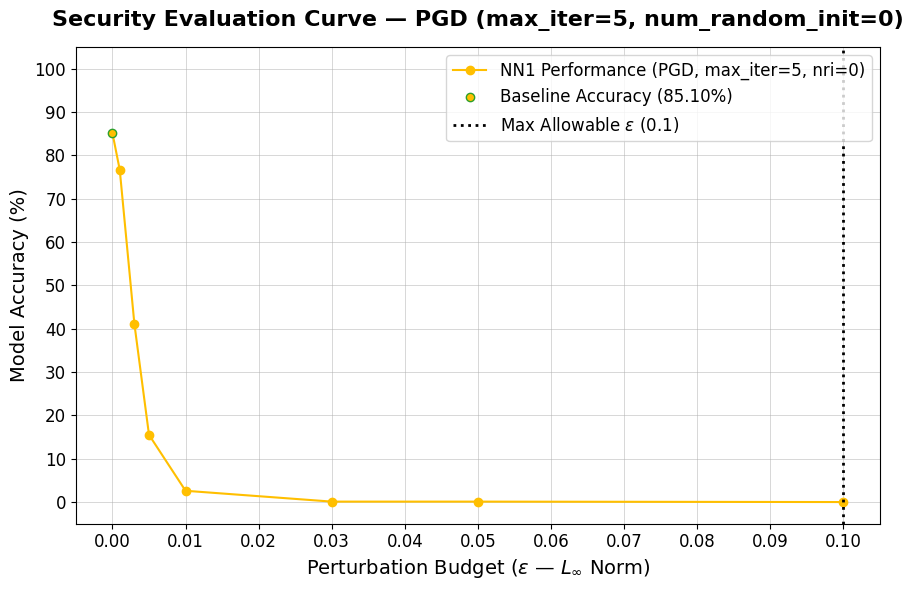


[INFO] Individual SEC saved at: ./results\PGD\PGD_nri0_iter5_SEC.png

MAX_ITER = 10 | NUM_RANDOM_INIT = 0

--- Evaluating Epsilon: 0.001 | max_iter: 10 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.001 | max_iter=10 | num_random_init=0: 76.70%

--- Evaluating Epsilon: 0.003 | max_iter: 10 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.003 | max_iter=10 | num_random_init=0: 40.30%

--- Evaluating Epsilon: 0.005 | max_iter: 10 | num_random_init: 0 ---


...

Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.030 | max_iter=10 | num_random_init=0: 0.10%

--- Evaluating Epsilon: 0.050 | max_iter: 10 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Accuracy at eps=0.050 | max_iter=10 | num_random_init=0: 0.10%

--- Evaluating Epsilon: 0.100 | max_iter: 10 | num_random_init: 0 ---


Processing Batches:   0%|          | 0/8 [00:00<?, ?it/s]

In [ ]:

# ==============================================================================
# STEP 3.3: Projected Gradient Descent (PGD) — Error-Generic Attack
# ==============================================================================

print("Initializing PGD Attack Pipeline...")

# ------------------------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------------------------
ATTACK_NAME        = "PGD"
BATCH_SIZE         = 128
EPSILONS           = [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1]
MAX_ITER_LIST      = [1, 5, 10, 20, 40]
NUM_RANDOM_INITS   = [0, 1, 3, 5]

# One color per max_iter — reused across all SEC plots
ITER_COLORS = {
    1:  '#1f77b4',
    5:  '#ffbf00',
    10: '#2ca02c',
    20: '#d62728',
    40: '#9467bd'
}

# One color per num_random_init — reused across all random_init plots
RAND_COLORS = {
    0: '#1f77b4',
    1: '#ff7f0e',
    3: '#2ca02c',
    5: '#d62728'
}

# Fixed epsilon values for hyperparameter effect plots (low, medium, high budget)
FIXED_EPSILONS_FOR_EFFECT = [0.01, 0.05, 0.1]
EPSILON_EFFECT_COLORS     = {
    0.01: '#9467bd',
    0.05: '#8c564b',
    0.1:  '#e377c2'
}

ATTACK_RESULTS_DIR = os.path.join(RESULTS_DIR, ATTACK_NAME)
os.makedirs(ATTACK_RESULTS_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# 2. Evaluation Loop
# all_accuracies[num_random_init][max_iter] -> list of accuracies, one per epsilon
# ------------------------------------------------------------------------------
print(f"\nStarting {ATTACK_NAME} generation across "
        f"{len(NUM_RANDOM_INITS)} num_random_init values x "
        f"{len(MAX_ITER_LIST)} max_iter values x "
        f"{len(EPSILONS)} epsilon values...")

results        = []
all_accuracies = {nri: {} for nri in NUM_RANDOM_INITS}

for num_random_init in NUM_RANDOM_INITS:
    print(f"\n{'#'*50}")
    print(f"NUM_RANDOM_INIT = {num_random_init}")
    print(f"{'#'*50}")

    for max_iter in MAX_ITER_LIST:
        print(f"\n{'='*50}")
        print(f"MAX_ITER = {max_iter} | NUM_RANDOM_INIT = {num_random_init}")
        print(f"{'='*50}")

        accuracies = []

        for eps in EPSILONS:
            print(f"\n--- Evaluating Epsilon: {eps:.3f} | max_iter: {max_iter} | num_random_init: {num_random_init} ---")

            eps_step = eps / max_iter

            pgd = ProjectedGradientDescentPyTorch(
                estimator=art_classifier,
                norm=np.inf,
                eps=eps,
                eps_step=eps_step,
                max_iter=max_iter,
                num_random_init=num_random_init,
                targeted=False,
                batch_size=BATCH_SIZE,
                verbose=False
            )

            correct_predictions = 0
            total_processed     = 0
            start_time          = time.time()

            for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Processing Batches"):
                batch_paths     = image_paths[i:i + BATCH_SIZE]
                batch_true_ids  = true_folder_ids[i:i + BATCH_SIZE]

                batch_tensors   = []
                batch_filenames = []
                for path in batch_paths:
                    img = Image.open(path).convert('RGB')
                    batch_tensors.append(preprocess_attack(img).numpy())
                    batch_filenames.append(os.path.basename(path))

                x_batch = np.stack(batch_tensors)
                x_adv   = pgd.generate(x=x_batch)

                preds        = art_classifier.predict(x_adv)
                pred_indices = np.argmax(preds, axis=1)

                for j, pred_idx in enumerate(pred_indices):
                    raw_label = LABELS[pred_idx]
                    if isinstance(raw_label, np.ndarray):
                        raw_label = raw_label.flatten()[0]
                    if isinstance(raw_label, bytes):
                        raw_label = raw_label.decode('utf-8')

                    predicted_name = (str(raw_label)
                                    .replace("b'", "").replace("'", "")
                                    .replace("[", "").replace("]", "").strip())
                    true_name = id_to_name.get(batch_true_ids[j], "Unknown")

                    if normalize_label(predicted_name) == normalize_label(true_name):
                        correct_predictions += 1

                save_adversarial_images(
                    x_adv, batch_true_ids, batch_filenames,
                    f"{ATTACK_NAME}_nri{num_random_init}_iter{max_iter}", eps
                )
                total_processed += len(batch_paths)

            elapsed = time.time() - start_time
            acc     = (correct_predictions / total_processed) * 100
            accuracies.append(acc)

            print(f"Accuracy at eps={eps:.3f} | max_iter={max_iter} | num_random_init={num_random_init}: {acc:.2f}%")

            results.append({
                'attack_name':         ATTACK_NAME,
                'num_random_init':     num_random_init,
                'max_iter':            max_iter,
                'eps_step':            round(eps / max_iter, 6),
                'epsilon':             eps,
                'correct_predictions': correct_predictions,
                'total_images':        total_processed,
                'accuracy':            round(acc, 2),
                'time_elapsed_s':      round(elapsed, 2)
            })

        all_accuracies[num_random_init][max_iter] = accuracies

        # ----------------------------------------------------------------------
        # 3. Individual SEC for this (num_random_init, max_iter) combination
        # ----------------------------------------------------------------------
        color = ITER_COLORS[max_iter]

        fig, ax = plt.subplots(figsize=(9, 6))

        ax.plot([0.0, EPSILONS[0]], [BASELINE_ACC, accuracies[0]],
                linestyle='-', color=color, linewidth=1.5)
        ax.plot(EPSILONS, accuracies,
                marker='o', linestyle='-', color=color,
                linewidth=1.5, markersize=6,
                label=f'NN1 Performance ({ATTACK_NAME}, max_iter={max_iter}, nri={num_random_init})')
        ax.plot(0.0, BASELINE_ACC,
                marker='o', markerfacecolor=color,
                markeredgecolor='#2ca02c', markeredgewidth=1,
                markersize=6, linestyle='None',
                label=f'Baseline Accuracy ({BASELINE_ACC:.2f}%)')

        ax.set_title(f'Security Evaluation Curve — {ATTACK_NAME} 'f'(max_iter={max_iter}, num_random_init={num_random_init})',fontsize=16, fontweight='bold', pad=15)
        ax.set_xlabel(r'Perturbation Budget ($\epsilon$ — $L_\infty$ Norm)', fontsize=14)
        ax.set_ylabel('Model Accuracy (%)', fontsize=14)
        ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
        ax.set_xticks(np.arange(0.0, 0.11, 0.01))
        ax.set_yticks(np.arange(0, 101, 10))
        ax.tick_params(axis='both', labelsize=12)
        ax.set_ylim(-5, 105)
        ax.set_xlim(-0.005, 0.105)
        ax.axvline(x=0.1, color='black', linestyle=':', linewidth=2, label=r'Max Allowable $\epsilon$ (0.1)')
        ax.legend(loc='upper right', fontsize=12)
        plt.tight_layout()

        plot_path = os.path.join(
            ATTACK_RESULTS_DIR,
            f'{ATTACK_NAME}_nri{num_random_init}_iter{max_iter}_SEC.png'
        )
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"\n[INFO] Individual SEC saved at: {plot_path}")

# ------------------------------------------------------------------------------
# 4. Comparative SEC per num_random_init — max_iter varies, epsilon on x-axis
#    For each fixed num_random_init, overlay all max_iter curves.
#    Ceteris paribus: num_random_init fixed, max_iter varies.
# ------------------------------------------------------------------------------
for num_random_init in NUM_RANDOM_INITS:
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(0.0, BASELINE_ACC,
            marker='o', markerfacecolor='black',
            markeredgecolor='#2ca02c', markeredgewidth=1,
            markersize=6, linestyle='None',
            label=f'Baseline Accuracy ({BASELINE_ACC:.2f}%)')

    for max_iter in MAX_ITER_LIST:
        color      = ITER_COLORS[max_iter]
        accuracies = all_accuracies[num_random_init][max_iter]
        ax.plot([0.0, EPSILONS[0]], [BASELINE_ACC, accuracies[0]],
                linestyle='-', color=color, linewidth=1.5)
        ax.plot(EPSILONS, accuracies,
                marker='o', linestyle='-', color=color,
                linewidth=1.5, markersize=6,
                label=f'max_iter={max_iter}')

    ax.set_title(f'SEC — {ATTACK_NAME} | num_random_init={num_random_init} (max_iter varies)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(r'Perturbation Budget ($\epsilon$ — $L_\infty$ Norm)', fontsize=14)
    ax.set_ylabel('Model Accuracy (%)', fontsize=14)
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    ax.set_xticks(np.arange(0.0, 0.11, 0.01))
    ax.set_yticks(np.arange(0, 101, 10))
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim(-5, 105)
    ax.set_xlim(-0.005, 0.105)
    ax.axvline(x=0.1, color='black', linestyle=':', linewidth=2, label=r'Max Allowable $\epsilon$ (0.1)')
    ax.legend(loc='upper right', fontsize=12)
    plt.tight_layout()

    path = os.path.join(ATTACK_RESULTS_DIR,
                        f'{ATTACK_NAME}_nri{num_random_init}_comparative_maxiter_SEC.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n[INFO] Comparative SEC (nri={num_random_init}, max_iter varies) saved at: {path}")

# ------------------------------------------------------------------------------
# 5. Comparative SEC per max_iter — num_random_init varies, epsilon on x-axis
#    For each fixed max_iter, overlay all num_random_init curves.
#    Ceteris paribus: max_iter fixed, num_random_init varies.
# ------------------------------------------------------------------------------
for max_iter in MAX_ITER_LIST:
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(0.0, BASELINE_ACC,
            marker='o', markerfacecolor='black',
            markeredgecolor='#2ca02c', markeredgewidth=1,
            markersize=6, linestyle='None',
            label=f'Baseline Accuracy ({BASELINE_ACC:.2f}%)')

    for num_random_init in NUM_RANDOM_INITS:
        color      = RAND_COLORS[num_random_init]
        accuracies = all_accuracies[num_random_init][max_iter]
        ax.plot([0.0, EPSILONS[0]], [BASELINE_ACC, accuracies[0]],
                linestyle='-', color=color, linewidth=1.5)
        ax.plot(EPSILONS, accuracies,
                marker='o', linestyle='-', color=color,
                linewidth=1.5, markersize=6,
                label=f'num_random_init={num_random_init}')

    ax.set_title(f'SEC — {ATTACK_NAME} | max_iter={max_iter} (num_random_init varies)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(r'Perturbation Budget ($\epsilon$ — $L_\infty$ Norm)', fontsize=14)
    ax.set_ylabel('Model Accuracy (%)', fontsize=14)
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    ax.set_xticks(np.arange(0.0, 0.11, 0.01))
    ax.set_yticks(np.arange(0, 101, 10))
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim(-5, 105)
    ax.set_xlim(-0.005, 0.105)
    ax.axvline(x=0.1, color='black', linestyle=':', linewidth=2, label=r'Max Allowable $\epsilon$ (0.1)')
    ax.legend(loc='upper right', fontsize=12)
    plt.tight_layout()

    path = os.path.join(ATTACK_RESULTS_DIR,
                        f'{ATTACK_NAME}_iter{max_iter}_comparative_nri_SEC.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n[INFO] Comparative SEC (max_iter={max_iter}, nri varies) saved at: {path}")

# ------------------------------------------------------------------------------
# 6. Hyperparameter Effect Plot — Accuracy vs max_iter at fixed epsilon values
#    num_random_init fixed at maximum value (5) — ceteris paribus.
# ------------------------------------------------------------------------------
FIXED_NRI_FOR_EFFECT = max(NUM_RANDOM_INITS)

fig, ax = plt.subplots(figsize=(9, 6))

for fixed_eps in FIXED_EPSILONS_FOR_EFFECT:
    eps_idx     = EPSILONS.index(fixed_eps)
    accs_at_eps = [all_accuracies[FIXED_NRI_FOR_EFFECT][m][eps_idx] for m in MAX_ITER_LIST]

    ax.plot(MAX_ITER_LIST, accs_at_eps,
            marker='o', linestyle='-',
            color=EPSILON_EFFECT_COLORS[fixed_eps],
            linewidth=1.5, markersize=6,
            label=rf'$\epsilon$ = {fixed_eps}')

ax.axhline(y=BASELINE_ACC, color='#2ca02c', linestyle='--',linewidth=1.5, label=f'Baseline Accuracy ({BASELINE_ACC:.2f}%)')

ax.set_title(f'Effect of max_iter on Model Accuracy — {ATTACK_NAME} 'f'(num_random_init={FIXED_NRI_FOR_EFFECT})',fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Iterations (max_iter)', fontsize=14)
ax.set_ylabel('Model Accuracy (%)', fontsize=14)
ax.set_xticks(MAX_ITER_LIST)
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(-5, 105)
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()

effect_iter_path = os.path.join(ATTACK_RESULTS_DIR,
                                f'{ATTACK_NAME}_maxiter_effect_nri{FIXED_NRI_FOR_EFFECT}.png')
plt.savefig(effect_iter_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n[INFO] max_iter effect plot saved at: {effect_iter_path}")

# ------------------------------------------------------------------------------
# 7. Hyperparameter Effect Plot — Accuracy vs num_random_init at fixed epsilon values
#    max_iter fixed at maximum value (40) — ceteris paribus.
# ------------------------------------------------------------------------------
FIXED_ITER_FOR_EFFECT = max(MAX_ITER_LIST)

fig, ax = plt.subplots(figsize=(9, 6))

for fixed_eps in FIXED_EPSILONS_FOR_EFFECT:
    eps_idx     = EPSILONS.index(fixed_eps)
    accs_at_eps = [all_accuracies[nri][FIXED_ITER_FOR_EFFECT][eps_idx] for nri in NUM_RANDOM_INITS]

    ax.plot(NUM_RANDOM_INITS, accs_at_eps,
            marker='o', linestyle='-',
            color=EPSILON_EFFECT_COLORS[fixed_eps],
            linewidth=1.5, markersize=6,
            label=rf'$\epsilon$ = {fixed_eps}')

ax.axhline(y=BASELINE_ACC, color='#2ca02c', linestyle='--',linewidth=1.5, label=f'Baseline Accuracy ({BASELINE_ACC:.2f}%)')

ax.set_title(f'Effect of num_random_init on Model Accuracy — {ATTACK_NAME} 'f'(max_iter={FIXED_ITER_FOR_EFFECT})',fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Random Restarts (num_random_init)', fontsize=14)
ax.set_ylabel('Model Accuracy (%)', fontsize=14)
ax.set_xticks(NUM_RANDOM_INITS)
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(-5, 105)
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()

effect_nri_path = os.path.join(ATTACK_RESULTS_DIR,f'{ATTACK_NAME}_nri_effect_iter{FIXED_ITER_FOR_EFFECT}.png')
plt.savefig(effect_nri_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n[INFO] num_random_init effect plot saved at: {effect_nri_path}")

# ------------------------------------------------------------------------------
# 8. Save Results CSV
# ------------------------------------------------------------------------------
df_results = pd.DataFrame(results)
csv_path   = os.path.join(ATTACK_RESULTS_DIR, f'{ATTACK_NAME}_results.csv')
df_results.to_csv(csv_path, index=False)
print(f"\n[INFO] Results CSV saved at: {csv_path}")

# ------------------------------------------------------------------------------
# 9. Attack Summary
# ------------------------------------------------------------------------------
print("\n" + "=" * 50)
print(f"{ATTACK_NAME} ATTACK SUMMARY REPORT")
print("=" * 50)
print(f"Evaluated Epsilon Range:   {EPSILONS[0]} to {EPSILONS[-1]}")
print(f"Max Iter Values:           {MAX_ITER_LIST}")
print(f"Num Random Init Values:    {NUM_RANDOM_INITS}")
print(f"Baseline Accuracy:         {BASELINE_ACC:.2f}%")
print("-" * 50)
for num_random_init in NUM_RANDOM_INITS:
    for max_iter in MAX_ITER_LIST:
        acc_worst = all_accuracies[num_random_init][max_iter][-1]
        print(f"  nri={num_random_init} | max_iter={max_iter:2d} — "
            f"Lowest Accuracy: {acc_worst:.2f}%  "
            f"(Degradation: {BASELINE_ACC - acc_worst:.2f}%)")
print("=" * 50 + "\n")


## Basic Iterative Method (BIM) — Error-Generic Attack

This step evaluates the effect of the BIM error-generic (untargeted) attack on NN1.
BIM extends FGSM by applying multiple smaller gradient steps, each of size
`eps_step = eps / max_iter`, staying within the L-infinity ball of radius epsilon.
The attack is evaluated across a range of epsilon values for each value of `max_iter`,
producing one Security Evaluation Curve per configuration, a comparative SEC overlaying
all curves, and a hyperparameter effect plot showing accuracy as a function of `max_iter`
at fixed epsilon values. A CSV summary of all results is written to the results directory.

Initializing BIM Attack Pipeline...

Starting BIM generation across 4 max_iter values x 7 epsilon values...

MAX_ITER = 1

--- Evaluating Epsilon: 0.001 | max_iter: 1 ---


Processing Batches:   0%|          | 0/32 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy at eps=0.100 | max_iter=1: 0.10%


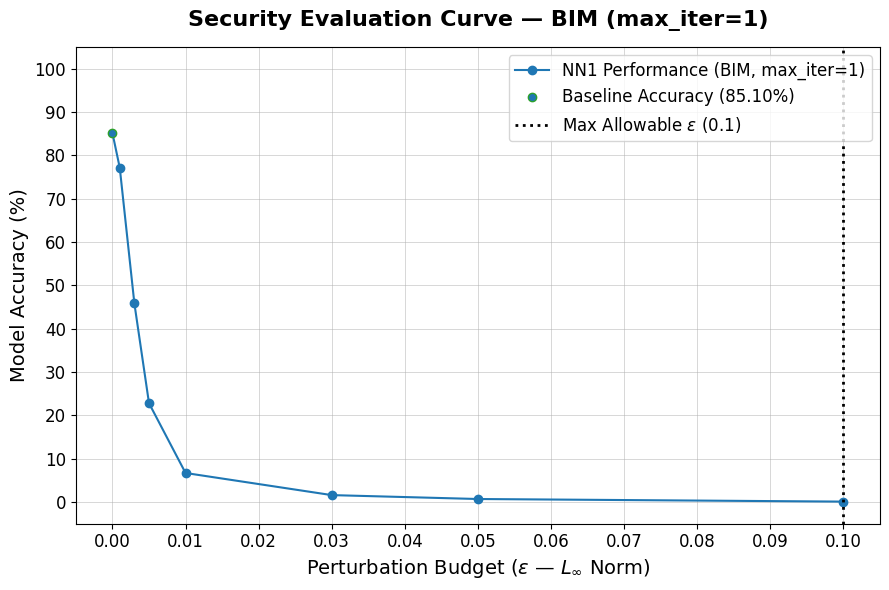


[INFO] Individual SEC saved at: ./results\BIM\BIM_iter1_SEC.png

MAX_ITER = 5

--- Evaluating Epsilon: 0.001 | max_iter: 5 ---


Processing Batches:   0%|          | 0/32 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy at eps=0.100 | max_iter=5: 0.00%


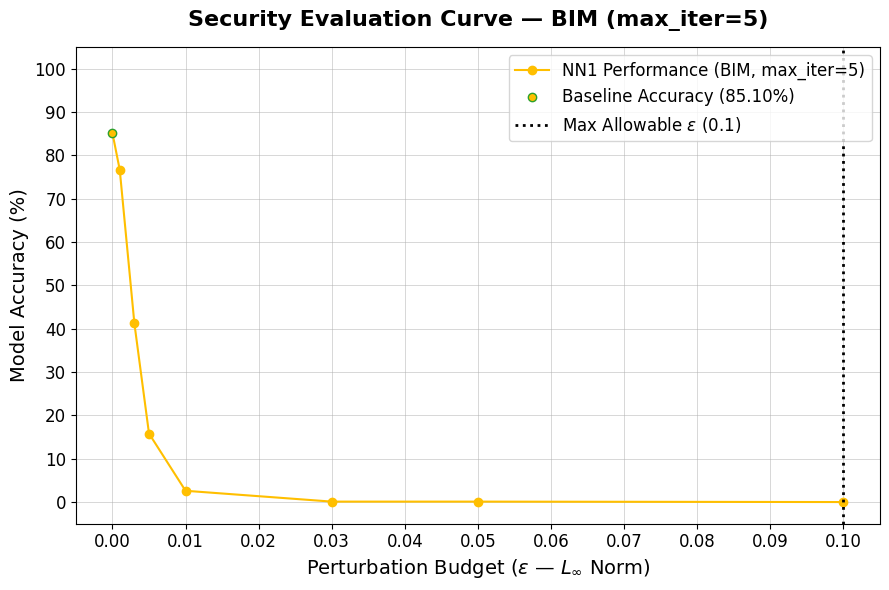


[INFO] Individual SEC saved at: ./results\BIM\BIM_iter5_SEC.png

MAX_ITER = 10

--- Evaluating Epsilon: 0.001 | max_iter: 10 ---


Processing Batches:   0%|          | 0/32 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy at eps=0.100 | max_iter=10: 0.00%


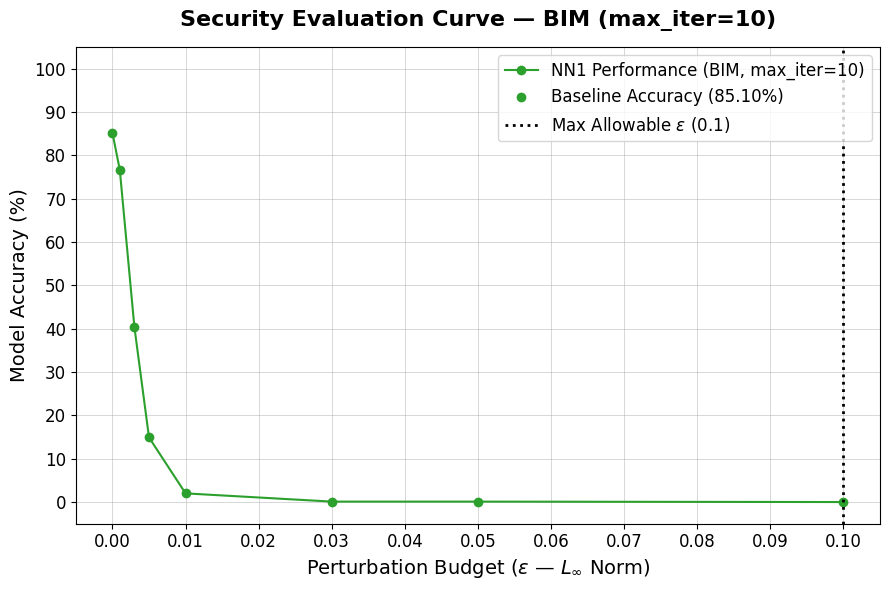


[INFO] Individual SEC saved at: ./results\BIM\BIM_iter10_SEC.png

MAX_ITER = 20

--- Evaluating Epsilon: 0.001 | max_iter: 20 ---


Processing Batches:   0%|          | 0/32 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy at eps=0.100 | max_iter=20: 0.10%


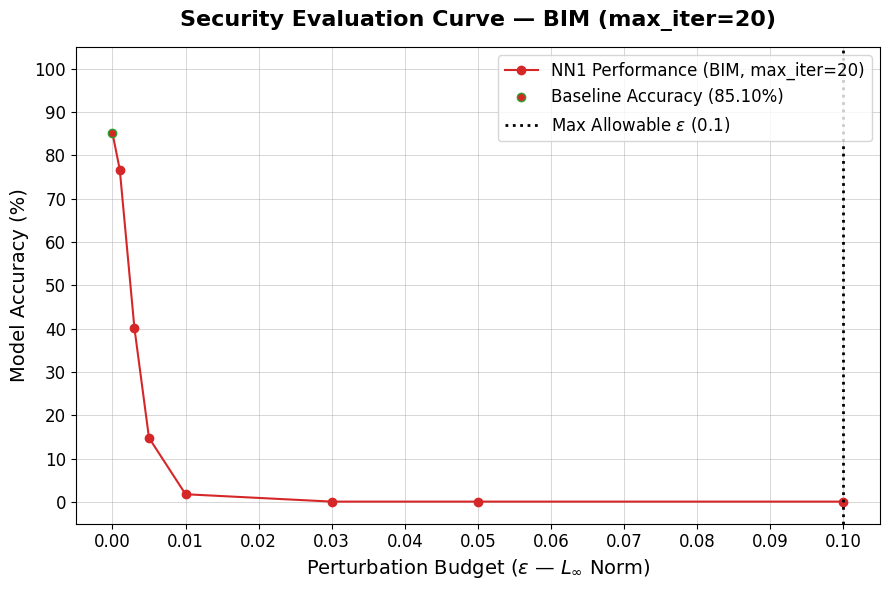


[INFO] Individual SEC saved at: ./results\BIM\BIM_iter20_SEC.png


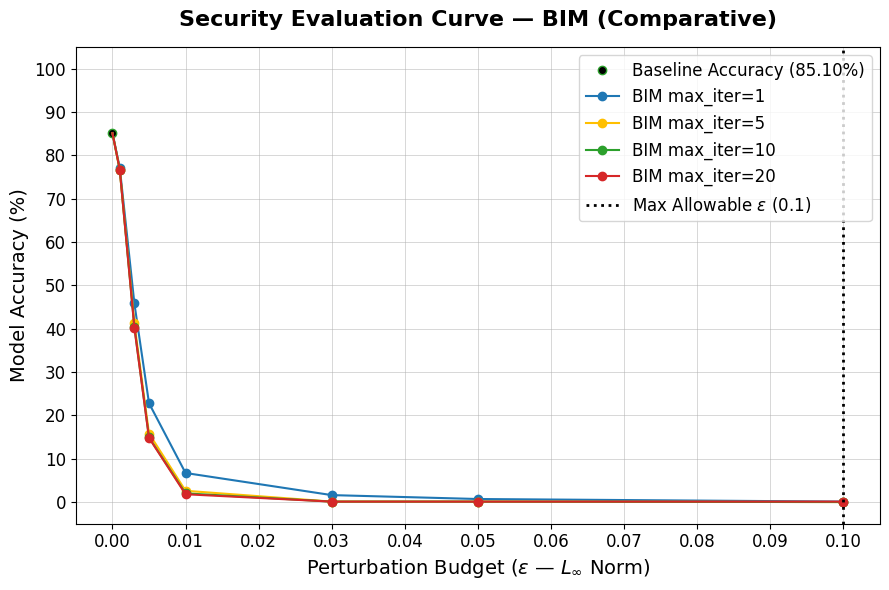


[INFO] Comparative SEC saved at: ./results\BIM\BIM_comparative_SEC.png


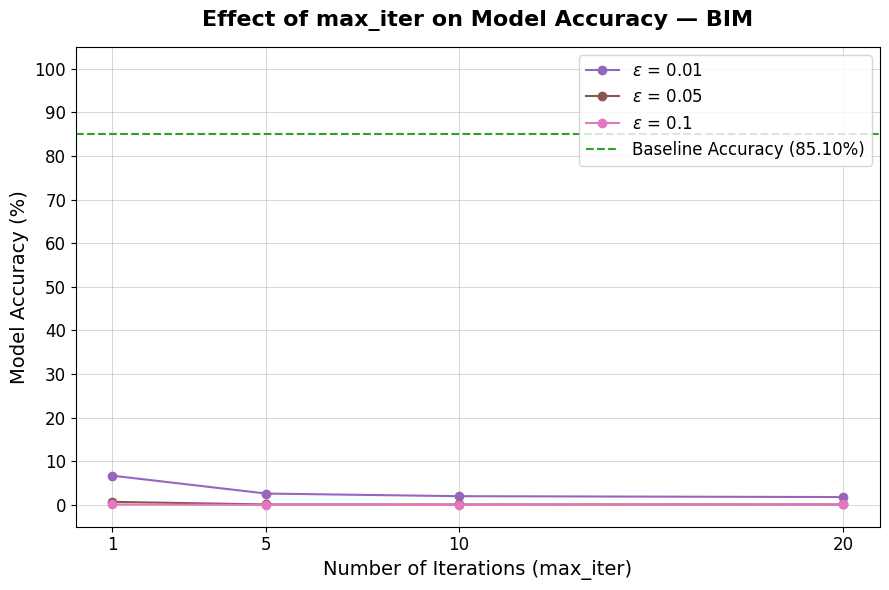


[INFO] Hyperparameter effect plot saved at: ./results\BIM\BIM_maxiter_effect.png

[INFO] Results CSV saved at: ./results\BIM\BIM_results.csv

BIM ATTACK SUMMARY REPORT
Evaluated Epsilon Range:  0.001 to 0.1
Max Iter Values:          [1, 5, 10, 20]
Baseline Accuracy:        85.10%
  max_iter= 1 — Lowest Accuracy: 0.10%  (Degradation: 85.00%)
  max_iter= 5 — Lowest Accuracy: 0.00%  (Degradation: 85.10%)
  max_iter=10 — Lowest Accuracy: 0.00%  (Degradation: 85.10%)
  max_iter=20 — Lowest Accuracy: 0.10%  (Degradation: 85.00%)



In [ ]:

# ==============================================================================
# Basic Iterative Method (BIM) — Error-Generic Attack
# ==============================================================================

print("Initializing BIM Attack Pipeline...")

# ------------------------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------------------------
ATTACK_NAME   = "BIM"
EPSILONS      = [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1]
MAX_ITER_LIST = [1, 5, 10, 20]

# One distinct color per max_iter value — reused across all plots for consistency
ITER_COLORS = {
    1:  '#1f77b4',
    5:  "#ffbf00",
    10: '#2ca02c',
    20: '#d62728'
}

# Fixed epsilon values used in the hyperparameter effect plot (low, medium, high budget)
FIXED_EPSILONS_FOR_EFFECT = [0.01, 0.05, 0.1]
EPSILON_EFFECT_COLORS     = {
    0.01: '#9467bd',
    0.05: '#8c564b',
    0.1:  '#e377c2'
}

ATTACK_RESULTS_DIR = os.path.join(RESULTS_DIR, ATTACK_NAME)
os.makedirs(ATTACK_RESULTS_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# 2. Evaluation Loop
# ------------------------------------------------------------------------------
print(f"\nStarting {ATTACK_NAME} generation across " f"{len(MAX_ITER_LIST)} max_iter values x {len(EPSILONS)} epsilon values...")

results        = []
all_accuracies = {}  # max_iter -> list of accuracies, one per epsilon

for max_iter in MAX_ITER_LIST:
    print(f"\n{'='*50}")
    print(f"MAX_ITER = {max_iter}")
    print(f"{'='*50}")

    accuracies = []

    for eps in EPSILONS:
        print(f"\n--- Evaluating Epsilon: {eps:.3f} | max_iter: {max_iter} ---")

        eps_step = eps / max_iter

        bim = BasicIterativeMethod(
            estimator=art_classifier,
            eps=eps,
            eps_step=eps_step,
            max_iter=max_iter
        )

        correct_predictions = 0
        total_processed     = 0
        start_time          = time.time()

        for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Processing Batches"):
            batch_paths     = image_paths[i:i + BATCH_SIZE]
            batch_true_ids  = true_folder_ids[i:i + BATCH_SIZE]

            batch_tensors   = []
            batch_filenames = []
            for path in batch_paths:
                img = Image.open(path).convert('RGB')
                batch_tensors.append(preprocess_attack(img).numpy())
                batch_filenames.append(os.path.basename(path))

            x_batch = np.stack(batch_tensors)
            x_adv   = bim.generate(x=x_batch)

            preds        = art_classifier.predict(x_adv)
            pred_indices = np.argmax(preds, axis=1)

            for j, pred_idx in enumerate(pred_indices):
                raw_label = LABELS[pred_idx]
                if isinstance(raw_label, np.ndarray):
                    raw_label = raw_label.flatten()[0]
                if isinstance(raw_label, bytes):
                    raw_label = raw_label.decode('utf-8')

                predicted_name = (str(raw_label)
                                .replace("b'", "").replace("'", "")
                                .replace("[", "").replace("]", "").strip())
                true_name = id_to_name.get(batch_true_ids[j], "Unknown")

                if normalize_label(predicted_name) == normalize_label(true_name):
                    correct_predictions += 1

            save_adversarial_images(
                x_adv, batch_true_ids, batch_filenames,
                f"{ATTACK_NAME}_iter{max_iter}", eps
            )
            total_processed += len(batch_paths)

        elapsed = time.time() - start_time
        acc     = (correct_predictions / total_processed) * 100
        accuracies.append(acc)

        print(f"Accuracy at eps={eps:.3f} | max_iter={max_iter}: {acc:.2f}%")

        results.append({
            'attack_name':         ATTACK_NAME,
            'max_iter':            max_iter,
            'eps_step':            round(eps / max_iter, 6),
            'epsilon':             eps,
            'correct_predictions': correct_predictions,
            'total_images':        total_processed,
            'accuracy':            round(acc, 2),
            'time_elapsed_s':      round(elapsed, 2)
        })

    all_accuracies[max_iter] = accuracies

    # --------------------------------------------------------------------------
    # 3. Individual SEC for this max_iter value
    # --------------------------------------------------------------------------
    color = ITER_COLORS[max_iter]

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot([0.0, EPSILONS[0]], [BASELINE_ACC, accuracies[0]],
            linestyle='-', color=color, linewidth=1.5)
    ax.plot(EPSILONS, accuracies,
            marker='o', linestyle='-', color=color,
            linewidth=1.5, markersize=6,
            label=f'NN1 Performance ({ATTACK_NAME}, max_iter={max_iter})')
    ax.plot(0.0, BASELINE_ACC,
            marker='o', markerfacecolor=color,
            markeredgecolor='#2ca02c', markeredgewidth=1,
            markersize=6, linestyle='None',
            label=f'Baseline Accuracy ({BASELINE_ACC:.2f}%)')

    ax.set_title(f'Security Evaluation Curve — {ATTACK_NAME} (max_iter={max_iter})',fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(r'Perturbation Budget ($\epsilon$ — $L_\infty$ Norm)', fontsize=14)
    ax.set_ylabel('Model Accuracy (%)', fontsize=14)
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    ax.set_xticks(np.arange(0.0, 0.11, 0.01))
    ax.set_yticks(np.arange(0, 101, 10))
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim(-5, 105)
    ax.set_xlim(-0.005, 0.105)
    ax.axvline(x=0.1, color='black', linestyle=':', linewidth=2,
            label=r'Max Allowable $\epsilon$ (0.1)')
    ax.legend(loc='upper right', fontsize=12)
    plt.tight_layout()

    plot_path = os.path.join(ATTACK_RESULTS_DIR, f'{ATTACK_NAME}_iter{max_iter}_SEC.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n[INFO] Individual SEC saved at: {plot_path}")

# ------------------------------------------------------------------------------
# 4. Comparative SEC — all max_iter curves overlaid, epsilon on x-axis
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(0.0, BASELINE_ACC,
        marker='o', markerfacecolor='black',
        markeredgecolor='#2ca02c', markeredgewidth=1,
        markersize=6, linestyle='None',
        label=f'Baseline Accuracy ({BASELINE_ACC:.2f}%)')

for max_iter, accuracies in all_accuracies.items():
    color = ITER_COLORS[max_iter]
    ax.plot([0.0, EPSILONS[0]], [BASELINE_ACC, accuracies[0]],
            linestyle='-', color=color, linewidth=1.5)
    ax.plot(EPSILONS, accuracies,
            marker='o', linestyle='-', color=color,
            linewidth=1.5, markersize=6,
            label=f'{ATTACK_NAME} max_iter={max_iter}')

ax.set_title(f'Security Evaluation Curve — {ATTACK_NAME} (Comparative)',fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel(r'Perturbation Budget ($\epsilon$ — $L_\infty$ Norm)', fontsize=14)
ax.set_ylabel('Model Accuracy (%)', fontsize=14)
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_xticks(np.arange(0.0, 0.11, 0.01))
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(-5, 105)
ax.set_xlim(-0.005, 0.105)
ax.axvline(x=0.1, color='black', linestyle=':', linewidth=2,label=r'Max Allowable $\epsilon$ (0.1)')
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()

comparative_path = os.path.join(ATTACK_RESULTS_DIR, f'{ATTACK_NAME}_comparative_SEC.png')
plt.savefig(comparative_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n[INFO] Comparative SEC saved at: {comparative_path}")

# ------------------------------------------------------------------------------
# 5. Hyperparameter Effect Plot — Accuracy vs max_iter at fixed epsilon values
#    eps_step = eps / max_iter for each point, all other parameters fixed.
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

for fixed_eps in FIXED_EPSILONS_FOR_EFFECT:
    eps_idx     = EPSILONS.index(fixed_eps)
    accs_at_eps = [all_accuracies[m][eps_idx] for m in MAX_ITER_LIST]

    ax.plot(MAX_ITER_LIST, accs_at_eps,
            marker='o', linestyle='-',
            color=EPSILON_EFFECT_COLORS[fixed_eps],
            linewidth=1.5, markersize=6,
            label=rf'$\epsilon$ = {fixed_eps}')

ax.axhline(y=BASELINE_ACC, color='#2ca02c', linestyle='--', linewidth=1.5, label=f'Baseline Accuracy ({BASELINE_ACC:.2f}%)')

ax.set_title(f'Effect of max_iter on Model Accuracy — {ATTACK_NAME}',fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Iterations (max_iter)', fontsize=14)
ax.set_ylabel('Model Accuracy (%)', fontsize=14)
ax.set_xticks(MAX_ITER_LIST)
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(-5, 105)
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()

effect_plot_path = os.path.join(ATTACK_RESULTS_DIR, f'{ATTACK_NAME}_maxiter_effect.png')
plt.savefig(effect_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n[INFO] Hyperparameter effect plot saved at: {effect_plot_path}")

# ------------------------------------------------------------------------------
# 6. Save Results CSV
# ------------------------------------------------------------------------------
df_results = pd.DataFrame(results)
csv_path   = os.path.join(ATTACK_RESULTS_DIR, f'{ATTACK_NAME}_results.csv')
df_results.to_csv(csv_path, index=False)
print(f"\n[INFO] Results CSV saved at: {csv_path}")

# ------------------------------------------------------------------------------
# 7. Attack Summary
# ------------------------------------------------------------------------------
print("\n" + "=" * 50)
print(f"{ATTACK_NAME} ATTACK SUMMARY REPORT")
print("=" * 50)
print(f"Evaluated Epsilon Range:  {EPSILONS[0]} to {EPSILONS[-1]}")
print(f"Max Iter Values:          {MAX_ITER_LIST}")
print(f"Baseline Accuracy:        {BASELINE_ACC:.2f}%")
for max_iter, accuracies in all_accuracies.items():
    print(f"  max_iter={max_iter:2d} — Lowest Accuracy: {accuracies[-1]:.2f}%  " f"(Degradation: {BASELINE_ACC - accuracies[-1]:.2f}%)")
print("=" * 50 + "\n")

In [ ]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# The visual range is [0.0, 1.0]. The maximum L_inf constraint is 0.1.
EPSILON_LIMIT = 0.1

print(f"--- START SCRIPT - WORKER {WORKER} on {device} ---")
print("\n[Phase 2] Preprocessing and loading images...")

preprocess_attack = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

x_data = []
y_labels_numeric = []
image_names = []

image_files = sorted([f for f in os.listdir(DATA_DIR_100) if f.lower().endswith(('.jpg', '.png'))])

if len(image_files) != 100:
    print(f"WARNING: Found {len(image_files)} images instead of 100!")

for img_name in image_files:
    img_path = os.path.join(DATA_DIR_100, img_name)

    img = Image.open(img_path).convert('RGB')
    img_tensor = preprocess_attack(img)
    x_data.append(img_tensor.numpy())
    image_names.append(img_name)

    class_id = os.path.splitext(img_name)[0].strip()

    if class_id in label_to_index:
        y_labels_numeric.append(label_to_index[class_id])
    else:
        print(f"Critical error: ID {class_id} not mapped.")
        y_labels_numeric.append(0)

x_data = np.array(x_data)
num_classes = len(LABELS)
y_data_one_hot = np.eye(num_classes)[y_labels_numeric]

print(f"Loaded {len(x_data)} images. Shape: {x_data.shape}")

# ==============================================================================
# WRAPPER ART AND BASELINE EVALUATION
# ==============================================================================
print("\n[Phase 3] Configuring ART Classifier...")

loss_fn = torch.nn.CrossEntropyLoss()

classifier = PyTorchClassifier(
    model=nn1,
    clip_values=(0.0, 1.0),
    loss=loss_fn,
    optimizer=None,
    input_shape=(3, 160, 160),
    nb_classes=num_classes,
    preprocessing=(np.array([0.5, 0.5, 0.5]), np.array([0.5, 0.5, 0.5])),
    device_type='gpu' if torch.cuda.is_available() else 'cpu'
)

if WORKER == "Christian":
    max_iter_list = [1]
    start_idx, end_idx = 0, 100
elif WORKER == "Salvatore":
    max_iter_list = [5]
    start_idx, end_idx = 0, 100
elif WORKER == "Candido":
    max_iter_list = [10]
    start_idx, end_idx = 0, 100
else:
    raise ValueError("Invalid WORKER.")

x_test_subset = x_data[start_idx:end_idx]
y_test_subset = y_data_one_hot[start_idx:end_idx]
image_names_subset = image_names[start_idx:end_idx]

print(f"Worker {WORKER}: assigned {len(x_test_subset)} images.")

# --- CLEAN BASELINE COMPUTATION ---
print("\nComputing baseline on original images...")
preds_clean = np.argmax(classifier.predict(x_test_subset), axis=1)
true_labels = np.argmax(y_test_subset, axis=1)
correct_clean_mask = (preds_clean == true_labels)
num_correct_clean = np.sum(correct_clean_mask)
baseline_acc = (num_correct_clean / len(x_test_subset)) * 100

print(f"Baseline Accuracy (Clean): {num_correct_clean}/{len(x_test_subset)} ({baseline_acc:.2f}%) correctly classified.")

# ==============================================================================
# GRID SEARCH CW L_INF (FILTER OUT L_INF > 0.10)
# ==============================================================================
print("\n[Phase 4] Starting C&W L_inf attack (skipping perturbations > 0.10)...")

learning_rate_list = [0.001, 0.01, 0.05, 0.1]
confidence_list = [0.0, 0.5, 1.0]

results = []
total_combinations = len(max_iter_list) * len(learning_rate_list) * len(confidence_list)
current_combo = 1

for m_iter in max_iter_list:
    for lr in learning_rate_list:
        for conf in confidence_list:
            print(f"\n[{current_combo}/{total_combinations}] Configuration: max_iter={m_iter}, lr={lr}, confidence={conf}")
            start_time_combo = time.time()

            # Build the output path string
            lr_str = str(lr).replace('.', '_')
            conf_str = str(conf).replace('.', '_')
            combo_dir_name = f"max_iter_{m_iter}_lr_{lr_str}_c_{conf_str}"

            output_images_dir = os.path.join(BASE_ADVERSARIAL_DIR, combo_dir_name)
            os.makedirs(output_images_dir, exist_ok=True)

            attack_cw = CarliniLInfMethod(
                classifier=classifier,
                targeted=False,
                max_iter=m_iter,
                learning_rate=lr,
                confidence=conf,
                verbose=False
            )

            x_adv_raw_list = []
            print(f"   -> Generating for {len(x_test_subset)} images...")

            # --- Generation loop with timing ---
            for i in range(len(x_test_subset)):
                start_img_time = time.time()

                single_adv = attack_cw.generate(x=x_test_subset[i:i+1])

                img_time = time.time() - start_img_time
                print(f"      - Image {i+1:02d}/{len(x_test_subset)} ({image_names_subset[i]}) processed in {img_time:.2f} seconds")

                x_adv_raw_list.append(single_adv)

            x_adv_raw = np.concatenate(x_adv_raw_list, axis=0)

            # Compute the raw perturbation without forced clipping
            perturbation_raw = x_adv_raw - x_test_subset

            l_inf_applied_list = []
            saved_count = 0

            # --- CHECK AND SAVE INDIVIDUAL IMAGES ---
            for i in range(len(x_adv_raw)):
                # Compute the L_inf perturbation for the i-th image
                l_inf_img = np.max(np.abs(perturbation_raw[i]))

                # Add 1e-5 to avoid float-precision issues (e.g. 0.1000001) discarding valid images
                if l_inf_img > EPSILON_LIMIT + 1e-5:
                    print(f"      - Image {image_names_subset[i]}: for this configuration the CW algorithm only found a perturbation larger than 0.10 (L_inf = {l_inf_img:.4f}) that fooled the network, so it was not saved in the current config folder.")
                    continue

                # If it passes the check, clip pixels to the visual range [0.0, 1.0] for saving
                adv_img_np = np.clip(x_adv_raw[i], 0.0, 1.0)

                # Conversion for PIL saving
                adv_img_np_save = np.transpose(adv_img_np, (1, 2, 0))
                adv_img_np_save = (adv_img_np_save * 255.0).astype(np.uint8)
                adv_pillow_img = Image.fromarray(adv_img_np_save)

                # Save
                img_save_path = os.path.join(output_images_dir, image_names_subset[i])
                adv_pillow_img.save(img_save_path)

                saved_count += 1

                # Compute the actual perturbation applied to the photo (after visual clipping to [0, 1])
                actual_perturbation = adv_img_np - x_test_subset[i]
                l_inf_applied_list.append(np.max(np.abs(actual_perturbation)))

            # Mean perturbation for this configuration (only on valid saved images)
            if saved_count > 0:
                mean_linf_applied = np.mean(l_inf_applied_list)
            else:
                mean_linf_applied = 0.0

            elapsed_time_combo = time.time() - start_time_combo

            # CSV log entry
            results.append({
                'WORKER': WORKER,
                'max_iter': m_iter,
                'learning_rate': lr,
                'confidence': conf,
                'Mean_Linf_Applied': round(mean_linf_applied, 4),
                'Time_Elapsed (s)': round(elapsed_time_combo, 2)
            })

            print(f" --> RESULT: Saved {saved_count}/{len(x_test_subset)} images | Mean L_inf applied: {mean_linf_applied:.4f} | Total Config Time: {elapsed_time_combo:.1f}s")
            current_combo += 1

# ==============================================================================
# PHASE 5: SAVE WORKER DATA
# ==============================================================================
df_results = pd.DataFrame(results)
csv_filename = f'cw_grid_search_worker_{WORKER}.csv'
csv_filepath = os.path.join(RESULTS_DIR, csv_filename)

df_results.to_csv(csv_filepath, index=False)

print("\n=======================================================")
print(f"Work completed! Results saved at:\n{csv_filepath}")
print("=======================================================")